# Predicting Diabetes Using Naive Bayes

### Objective
- Apply Naive Bayes for binary classification.
- Practice data exploration and preprocessing.
- Evaluate model performance using appropriate metrics.
- Understand and interpret the log probabilities used in Naive Bayes.

### Dataset
This lab uses the Pima Indians Diabetes Dataset from the UCI Machine Learning Repository. It contains 8 features based on medical information, with a binary target indicating the presence of diabetes (1) or absence (0).

### Features
`Pregnancies`: Number of times pregnant
`Glucose`: Plasma glucose concentration
`BloodPressure`: Diastolic blood pressure (mm Hg)
`SkinThickness`: Triceps skinfold thickness (mm)
`Insulin`: 2-Hour serum insulin (mu U/ml)
`BMI`: Body mass index (weight in kg/(height in m)^2)
`DiabetesPedigreeFunction`: Diabetes pedigree function (a function based on family history)
`Age`: Age (years)
`Outcome`: Class variable (1 if patient has diabetes, 0 otherwise)

### Import packages

In [2]:
# Import the necessary libraries for data manipulation, model training, and evaluation.
# your code here

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading and Exploration

In [7]:
# Load the Pima Indiands Diabetes Dataset in the folder ../data and preview the data
# Display summary statistics
# your code here
df = pd.read_csv("../data/pima_diabetes.csv")

# Preview the first 5 rows
print("Preview of the dataset:")
print(df.head())

# Display summary statistics
print("\nSummary Statistics:")
print(df.describe())


Preview of the dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Summary Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618

### Data Cleaning

1. *Handling Missing Values*: Replace 0 values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI columns with their respective median values.
2. *Split Data*: Separate the feature columns (X) and target (y), and then split into training and test sets with an 80-20 split.

In [8]:
# your code here

# Load dataset
df = pd.read_csv("../data/pima_diabetes.csv")

# Columns where 0 means "missing"
cols_with_zero_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace 0 with median of each column
for col in cols_with_zero_missing:
    median_value = df[col].median()
    df[col] = df[col].replace(0, median_value)

# Separate features and target
X = df.drop(columns="Outcome")
y = df["Outcome"]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (614, 8)
Test set shape: (154, 8)


### Train a Naïve Bayes Classifier

Since the features are continuous, we need to use the `GaussianNB` model instead of the ones we used so far for categorical variables

In [15]:
# your code here
from sklearn.naive_bayes import GaussianNB

# Create the model
nb_classifier = GaussianNB()

# Train the model
nb_classifier.fit(X_train, y_train)

# Predictions
y_pred_train = nb_classifier.predict(X_train)
y_pred_test = nb_classifier.predict(X_test)

### Model Evaluation

Evaluate the model's accuracy, precision and recall. Analyse the confusion matrix.
Give the setting of the problem, which metrics would you privilege?

In [16]:
# your code here
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report


# Accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Precision & Recall
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)

print("\nPrecision:", precision)
print("Recall:", recall)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
print("\nConfusion Matrix:\n", cm)

# Full classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))




Training Accuracy: 0.747557003257329
Test Accuracy: 0.7532467532467533

Precision: 0.6440677966101694
Recall: 0.6909090909090909

Confusion Matrix:
 [[78 21]
 [17 38]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.80        99
           1       0.64      0.69      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154



### Exploring Log Probabilities in Naïve Bayes

Naive Bayes calculates log probabilities (logprobs) for each class to make predictions. Let's use `predict_log_proba` to calculate the log probabilities for each class (diabetes vs. no diabetes) for a few samples in the test set.

Question: For a given instance in the test set, calculate the log probabilities for each class (diabetes vs. no diabetes) and interpret the values. How does Naive Bayes decide the predicted class based on these log probabilities?

In [19]:
# Select a few samples from the test set
sample_indices = [0, 1, 12, 20, 32]  # Change these indices as desired
X_sample = X_test.iloc[sample_indices]

# Calculate log probabilities for each class
log_probs = nb_classifier.predict_log_proba(X_sample)

# Display results
for i, index in enumerate(sample_indices):
    print(f"Sample {index} - Log Probabilities:")
    print(f"No Diabetes (0): {log_probs[i][0]:.4f}, Diabetes (1): {log_probs[i][1]:.4f}")
    print(f"Predicted Class: {nb_classifier.predict(X_sample.iloc[[i]])[0]}")
    print()

Sample 0 - Log Probabilities:
No Diabetes (0): -0.2415, Diabetes (1): -1.5391
Predicted Class: 0

Sample 1 - Log Probabilities:
No Diabetes (0): -0.0728, Diabetes (1): -2.6562
Predicted Class: 0

Sample 12 - Log Probabilities:
No Diabetes (0): -0.9818, Diabetes (1): -0.4694
Predicted Class: 1

Sample 20 - Log Probabilities:
No Diabetes (0): -0.1091, Diabetes (1): -2.2696
Predicted Class: 0

Sample 32 - Log Probabilities:
No Diabetes (0): -4.1707, Diabetes (1): -0.0156
Predicted Class: 1



- Interpretation of Log Probabilities: Log probabilities represent the logarithm of the probability for each class. A higher log probability (closer to zero, since log values are negative) indicates a higher likelihood for that class.
- Decision-Making: The model predicts the class with the highest log probability. If the log probability for Diabetes (1) is higher (closer to zero) than for No Diabetes (0), the model will predict Diabetes (1).

Convert log probabilities back to regular probabilities using np.exp(log_probs) to see how log transformations aid computation without changing predictions.

In [20]:
# your code here
# Convert log probabilities back to regular probabilities using np.exp(log_probs) to see how log transformations aid computation without changing predictions.
probs = np.exp(log_probs)

for i, index in enumerate(sample_indices):
    print(f"Sample {index} - Probabilities:")
    print(f"No Diabetes (0): {probs[i][0]:.4f}, Diabetes (1): {probs[i][1]:.4f}")
    print()


Sample 0 - Probabilities:
No Diabetes (0): 0.7854, Diabetes (1): 0.2146

Sample 1 - Probabilities:
No Diabetes (0): 0.9298, Diabetes (1): 0.0702

Sample 12 - Probabilities:
No Diabetes (0): 0.3746, Diabetes (1): 0.6254

Sample 20 - Probabilities:
No Diabetes (0): 0.8967, Diabetes (1): 0.1033

Sample 32 - Probabilities:
No Diabetes (0): 0.0154, Diabetes (1): 0.9846



Change your decision treshold so that either class 1 or 0 becomes more frequent in order to optimize your preferred metric (precision or recall) for this problem. Try multiple tresholds until you are satisfied with your choice.

In [22]:
treshold = 0.5 # adjust this number to make it easier/harder to classify someone as diabetic


# Calculate log probabilities for each class
log_probs = nb_classifier.predict_log_proba(X_test)

#compute probability of No Diabetes (0) vs Diabetes (1)
probabilities = []
for i, index in enumerate(X_test.index):
    prediction = 0 if np.exp(log_probs[i][0]) >= treshold else 1
    probabilities.append({'index':index,'no_diab_prob': np.exp(log_probs[i][0]), 'diab_prob': np.exp(log_probs[i][1]), 'prediction':prediction})

probabilities = pd.DataFrame(probabilities)
probabilities.head()

,index,no_diab_prob,diab_prob,prediction
0,668,0.785426,0.214574,0
1,324,0.929784,0.070216,0
2,624,0.981480,0.018520,0
3,690,0.848221,0.151779,0
4,473,0.451266,0.548734,1


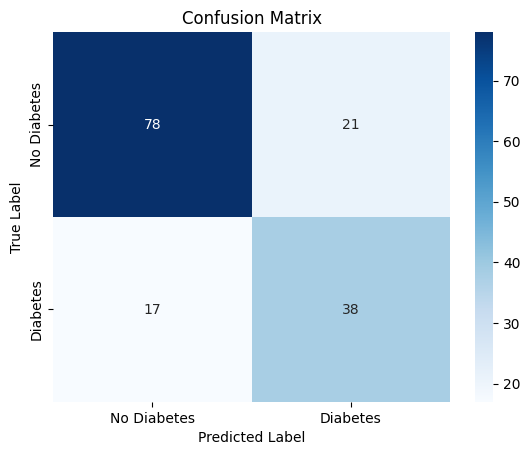

In [23]:
# create the confusion matrix for the adjusted problem
y_pred_adjusted = probabilities['prediction']
cm = confusion_matrix(y_test, y_pred_adjusted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()